## Loading Data and Preprocessing

In [39]:

from pandas import DataFrame
import pandas as pd
master_df = pd.read_csv(r"C:\Users\danma\Downloads\Master_Stock_Dataset_Expanded.csv", index_col='date', parse_dates=True)

## Exploration

In [40]:
df=master_df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 400 entries, 2025-12-17 to 2026-04-14
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   open                  400 non-null    float64
 1   high                  400 non-null    float64
 2   low                   400 non-null    float64
 3   close                 400 non-null    float64
 4   volume                400 non-null    float64
 5   symbol                400 non-null    object 
 6   RSI                   400 non-null    float64
 7   MA20                  400 non-null    float64
 8   std                   400 non-null    float64
 9   Upper_Band            400 non-null    float64
 10  Lower_Band            400 non-null    float64
 11  SMA20                 400 non-null    float64
 12  EMA20                 400 non-null    float64
 13  MACD                  400 non-null    float64
 14  MACD_signal           400 non-null    float64
 15  futu

In [41]:
df.shape

(400, 26)

In [42]:
df.describe()

,open,high,low,close,volume,RSI,MA20,std,Upper_Band,Lower_Band,...,future_low,downside_risk,MarketCapitalization,PERatio,ProfitMargin,OperatingMarginTTM,reportedEPS,estimatedEPS,surprise,surprisePercentage
count,400.000000,400.000000,400.000000,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,280.476788,283.598834,277.174695,280.481325,6.684076e+07,45.573979,283.904135,8.104419,300.112972,267.695298,...,271.674765,-0.032228,3.641484e+12,32.296000,0.330400,0.379200,2.619400,2.474475,0.144925,5.878258
std,85.851972,86.348871,85.015618,85.658520,5.973487e+07,16.009878,89.229272,5.214805,94.690540,84.705260,...,84.070373,0.022001,7.637256e+11,4.654794,0.146856,0.179989,0.902915,0.850926,0.107358,4.895370
min,166.970000,169.450000,164.270000,165.170000,5.855880e+06,6.467181,177.146000,2.562349,187.203124,163.801934,...,164.270000,-0.125843,2.678024e+12,24.570000,0.108000,0.105000,1.300000,1.240000,0.000000,0.000000
25%,208.286250,211.372500,205.873750,208.752500,3.097929e+07,34.958650,210.830000,4.995116,219.626389,197.644564,...,202.480000,-0.043256,2.921742e+12,30.770000,0.270000,0.316000,1.950000,1.950000,0.060000,4.838700
50%,259.367500,262.040000,257.120000,260.310000,4.121257e+07,45.988716,263.048500,6.129775,280.183418,247.605537,...,255.190000,-0.028158,3.804264e+12,32.800000,0.328000,0.354000,2.820000,2.630000,0.170000,6.367000
75%,320.940000,330.334700,319.493850,324.600000,6.719453e+07,55.601306,322.836750,9.440995,343.234894,301.162603,...,310.730000,-0.015717,4.027212e+12,34.730000,0.390000,0.471000,2.840000,2.670000,0.190000,6.578900
max,487.840000,489.700000,485.960000,488.020000,3.608079e+08,89.342466,483.940500,29.548886,504.028263,473.305860,...,484.180000,-0.001003,4.776176e+12,38.610000,0.556000,0.650000,4.140000,3.920000,0.550000,26.623400


## Visuals

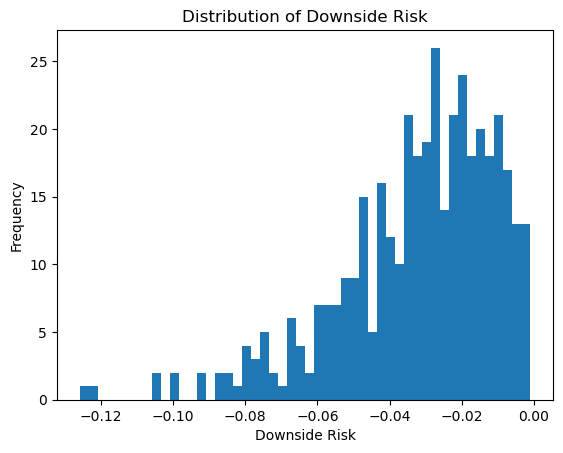

In [43]:
import matplotlib.pyplot as plt

plt.hist(df['downside_risk'], bins=50)
plt.title("Distribution of Downside Risk")
plt.xlabel("Downside Risk")
plt.ylabel("Frequency")
plt.show()

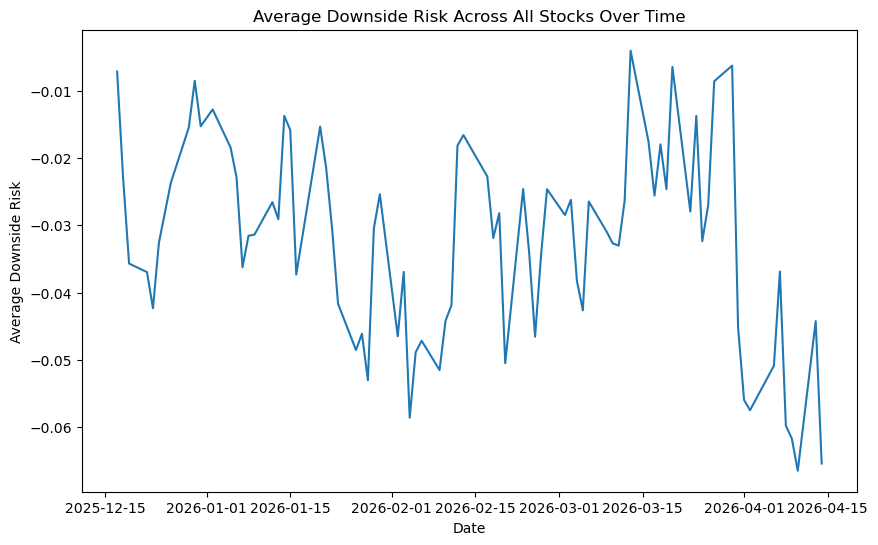

In [44]:
# group by date and average across all tickers
daily_avg = df.groupby(df.index)['downside_risk'].mean()

plt.figure(figsize=(10,6))
plt.plot(daily_avg.index, daily_avg.values)

plt.title("Average Downside Risk Across All Stocks Over Time")
plt.xlabel("Date")
plt.ylabel("Average Downside Risk")

plt.show()

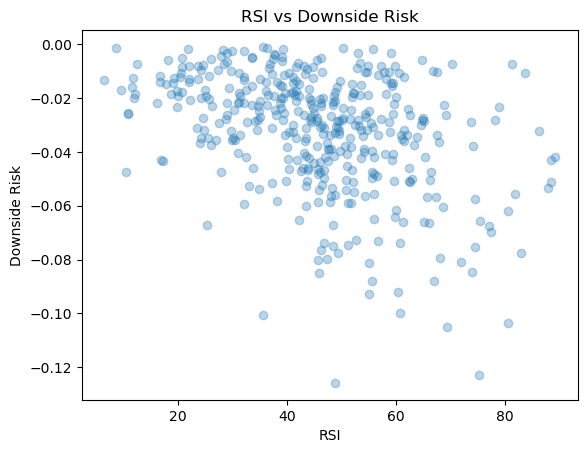

In [45]:
plt.scatter(df['RSI'], df['downside_risk'], alpha=0.3)
plt.title("RSI vs Downside Risk")
plt.xlabel("RSI")
plt.ylabel("Downside Risk")
plt.show()

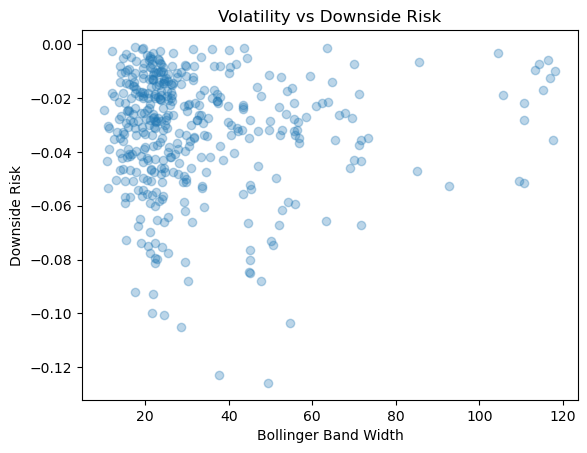

In [46]:
df['band_width'] = df['Upper_Band'] - df['Lower_Band']

plt.scatter(df['band_width'], df['downside_risk'], alpha=0.3)
plt.title("Volatility vs Downside Risk")
plt.xlabel("Bollinger Band Width")
plt.ylabel("Downside Risk")
plt.show()

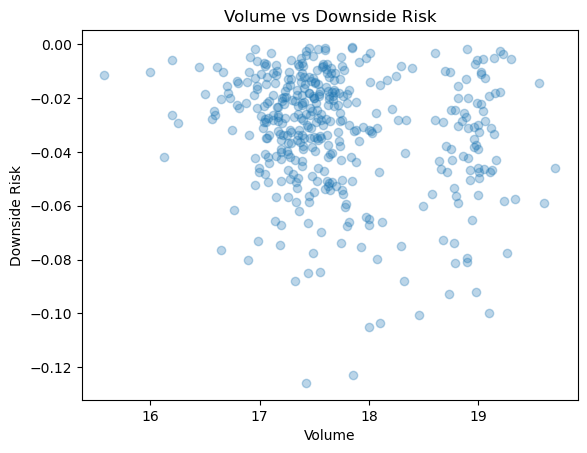

In [47]:
import numpy as np
plt.scatter(np.log1p(df['volume']), df['downside_risk'], alpha=0.3)
plt.title("Volume vs Downside Risk")
plt.xlabel("Volume")
plt.ylabel("Downside Risk")
plt.show()

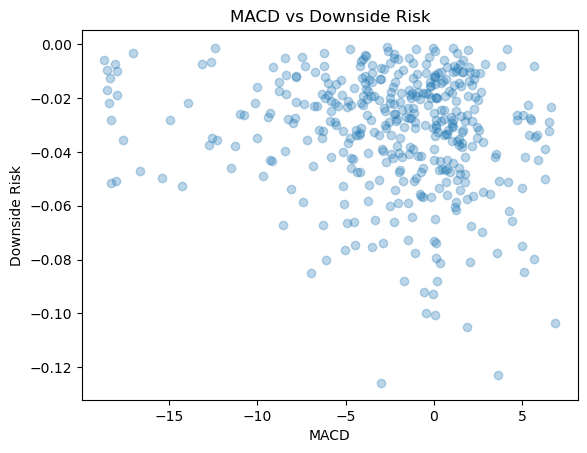

In [48]:
plt.scatter(df['MACD'], df['downside_risk'], alpha=0.3)
plt.title("MACD vs Downside Risk")
plt.xlabel("MACD")
plt.ylabel("Downside Risk")
plt.show()

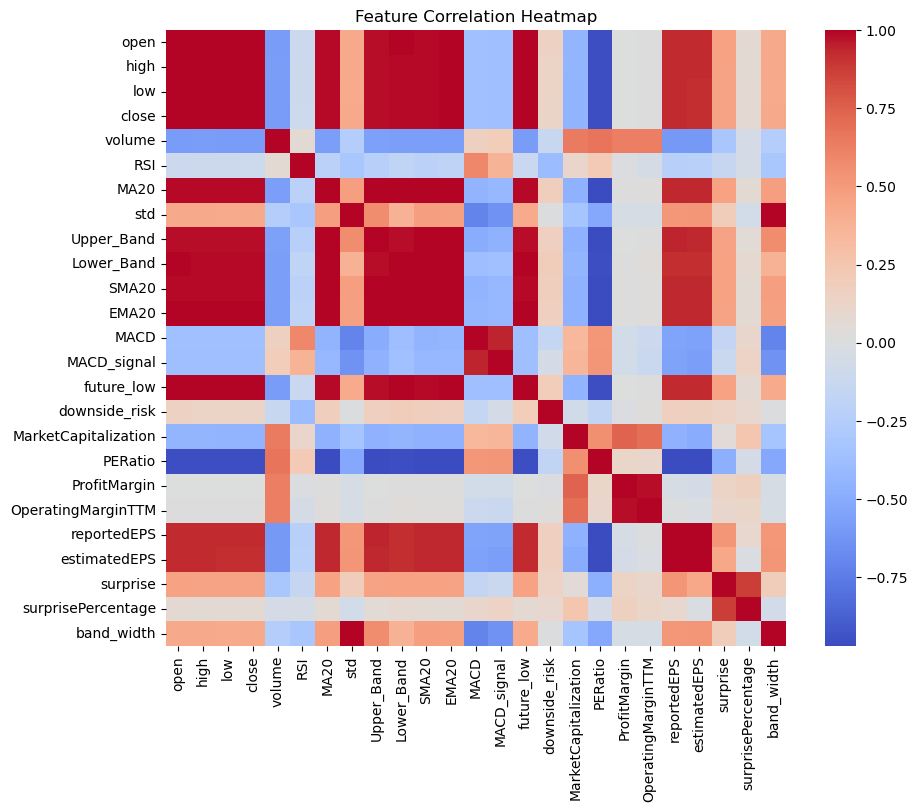

In [49]:
import seaborn as sns

corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [50]:
#Find date of the highest risk
worst_row = df.loc[df['downside_risk'].idxmin()]

print(worst_row)

               open     high     low   close       volume symbol        RSI  \
date                                                                          
2026-01-28  257.650  258.855  254.51  256.44   41287971.0   AAPL  43.858541   
2026-01-28  483.210  483.740  478.00  481.63   36875403.0   MSFT  48.925485   
2026-01-28  191.270  192.350  189.84  191.52  148552677.0   NVDA  53.291450   
2026-01-28  336.060  337.535  331.94  336.01   27434434.0  GOOGL  64.865438   
2026-01-28  246.365  247.775  241.53  243.01   40882657.0   AMZN  51.648851   

                MA20        std  Upper_Band  ...  MarketCapitalization  \
date                                         ...                         
2026-01-28  259.0085   7.753682  274.515864  ...          3.804264e+12   
2026-01-28  470.4110  12.322532  495.056064  ...          2.921742e+12   
2026-01-28  186.2420   2.802596  191.847192  ...          4.776176e+12   
2026-01-28  326.3995   8.092312  342.584124  ...          4.027212e+12   
20

In [51]:
df.nsmallest(10, 'downside_risk')[['symbol','downside_risk']].head(10)

,symbol,downside_risk
date,,
2026-01-28,MSFT,-0.125843
2026-04-10,AMZN,-0.122934
2026-04-09,AMZN,-0.105179
2026-04-14,AMZN,-0.103405
2026-02-05,AMZN,-0.100498
2026-02-09,NVDA,-0.100032
2026-02-10,NVDA,-0.092872
2025-12-23,NVDA,-0.091908
2026-02-04,AAPL,-0.087924


## Data Cleaning

In [52]:
# VOLATILITY (replace Upper/Lower bands)
df['band_width'] = df['Upper_Band'] - df['Lower_Band']

# TREND (use one, not both SMA/EMA raw)
df['price_vs_ma'] = df['close'] / df['SMA20']  # or EMA20

# MOMENTUM
df['macd_diff'] = df['MACD'] - df['MACD_signal']

# VOLUME (nonlinear -> spike)
df['volume_spike'] = df['volume'] / df['volume'].rolling(10).mean()

# EARNINGS (already good)
df['eps_surprise_ratio'] = df['surprisePercentage']

In [53]:
drop_cols = [
    'open','high','low',                 # redundant with close
    'Upper_Band','Lower_Band',           # replaced by band_width
    'SMA20','EMA20',                     # replaced by price_vs_ma
    # keep either MACD+signal OR macd_diff; not all three
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [54]:
features = [
    # core
    'close',
    'volume',

    # technical
    'RSI',
    'band_width',
    'price_vs_ma',
    'macd_diff',          # or MACD + MACD_signal
    'volume_spike',

    # fundamentals (minimal, meaningful)
    'PERatio',
    'eps_surprise_ratio'
]

features = [f for f in features if f in df.columns]

X = df[features]
y = df['downside_risk']

In [55]:
print(X.describe().T[['mean','std','min','max']])
print(X.isna().sum())

                            mean           std           min           max
close               2.804813e+02  8.565852e+01  1.651700e+02  4.880200e+02
volume              6.684076e+07  5.973487e+07  5.855880e+06  3.608079e+08
RSI                 4.557398e+01  1.600988e+01  6.467181e+00  8.934247e+01
band_width          3.241767e+01  2.085922e+01  1.024940e+01  1.181955e+02
price_vs_ma         9.910728e-01  4.126351e-02  8.702495e-01  1.154613e+00
macd_diff          -1.478450e-01  1.712201e+00 -6.385956e+00  4.915263e+00
volume_spike        1.021440e+00  4.223541e-01  1.309236e-01  4.653340e+00
PERatio             3.229600e+01  4.654794e+00  2.457000e+01  3.861000e+01
eps_surprise_ratio  5.878258e+00  4.895370e+00  0.000000e+00  2.662340e+01
close                 0
volume                0
RSI                   0
band_width            0
price_vs_ma           0
macd_diff             0
volume_spike          9
PERatio               0
eps_surprise_ratio    0
dtype: int64


In [56]:
X = X.fillna(X.median(numeric_only=True))

In [57]:
basic_features = ['close', 'volume', 'PERatio']

technical_features = [
    'close',
    'volume',
    'RSI',
    'band_width',
    'price_vs_ma',
    'macd_diff',
    'volume_spike'
]

full_features = [
    'close',
    'volume',
    'RSI',
    'band_width',
    'price_vs_ma',
    'macd_diff',
    'volume_spike',
    'PERatio',
    'eps_surprise_ratio'
]

feature_sets = {
    'Basic': basic_features,
    'Technical': technical_features,
    'Full': full_features
}

# Modeling

## Linear Regression

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

# evaluation
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 0.012488187984688343
RMSE: 0.015740019661214723
R2: 0.4241501239851342


In [59]:
results_random = []

results_random.append({
    'Model': 'Linear',
    'Split': 'Random',
    'Feature Set': 'Full',
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    'R2': r2_score(y_test, y_pred_lr)
})

## Random Forest

In [60]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# evaluation
print("Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest
MAE: 0.0125357502642125
RMSE: 0.015410916028121223
R2: 0.44797894249495884


In [61]:
results_random.append({
    'Split': 'Random',
    'Model': 'Random Forest',
    'Feature Set': 'Full',
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'R2': r2_score(y_test, y_pred_rf)
})

## Gradient Boosting

In [62]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

# evaluation
print("Gradient Boosting")
print("MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("R2:", r2_score(y_test, y_pred_gbr))

Gradient Boosting
MAE: 0.012893294136727925
RMSE: 0.01573834103120977
R2: 0.4242729430611374


In [63]:
results_random.append({
    'Model': 'Gradient Boosting',
    'Split': 'Random',
    'Feature Set': 'Full',
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    'R2': r2_score(y_test, y_pred_lr)
})

# Models based on time split

### Time Split Pre Process

In [64]:
unique_dates = sorted(df.index.unique())
cutoff_date = unique_dates[int(len(unique_dates) * 0.8)]

train_df = df[df.index < cutoff_date]
test_df = df[df.index >= cutoff_date]

## Linear Regression

#### Test of all variables

In [65]:
results_lr = []

for name, cols in feature_sets.items():
    cols = [c for c in cols if c in df.columns]

    X_train = train_df[cols].copy()
    X_test = test_df[cols].copy()
    y_train = train_df['downside_risk']
    y_test = test_df['downside_risk']

    X_train = X_train.fillna(X_train.median())
    X_test = X_test.fillna(X_train.median())

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results_lr.append({
        'Feature Set': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })

results_lr = pd.DataFrame(results_lr)
print(results_lr)

  Feature Set       MAE      RMSE        R2
0       Basic  0.022063  0.028631 -0.142199
1   Technical  0.014991  0.019179  0.487459
2        Full  0.014319  0.018447  0.525832


#### Feature Importance

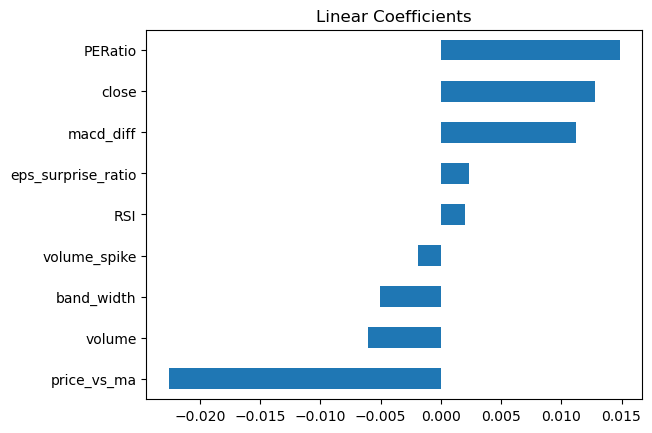

In [66]:
cols = feature_sets['Full']

X_train = train_df[cols].copy()
y_train = train_df['downside_risk']

X_train = X_train.fillna(X_train.median())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

coeffs = pd.Series(lr.coef_, index=cols)

coeffs.sort_values().plot(kind='barh')
plt.title("Linear Coefficients")
plt.show()

#### Residual Analysis

In [67]:
cols = feature_sets['Full']

X_train = train_df[cols].copy()
X_test = test_df[cols].copy()
y_train = train_df['downside_risk']
y_test = test_df['downside_risk']

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

residuals = y_test - y_pred

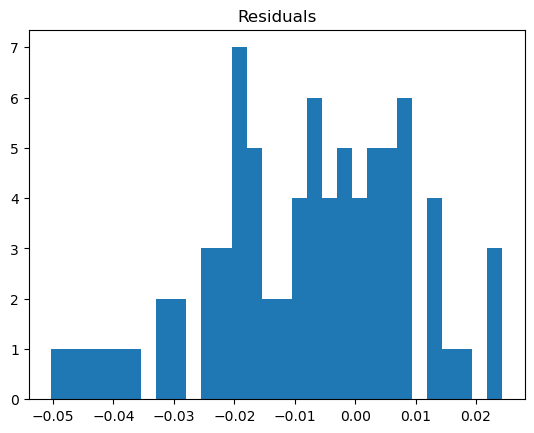

In [68]:
plt.hist(residuals, bins=30)
plt.title("Residuals")
plt.show()

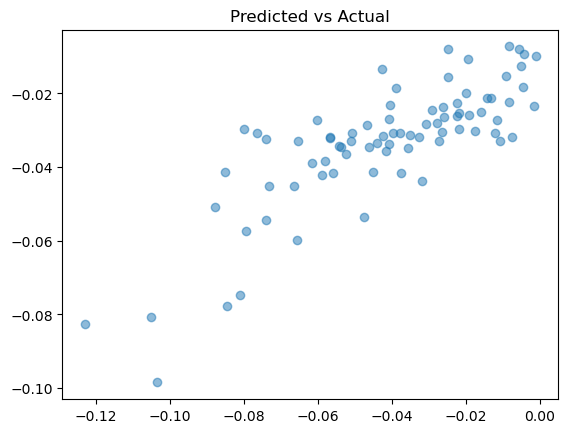

In [69]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title("Predicted vs Actual")
plt.show()

## Random Forest

#### Test of different variables

In [70]:
results_rf = []

for name, cols in feature_sets.items():
    cols = [c for c in cols if c in df.columns]

    X_train = train_df[cols].copy()
    X_test = test_df[cols].copy()
    y_train = train_df['downside_risk']
    y_test = test_df['downside_risk']

    X_train = X_train.fillna(X_train.median())
    X_test = X_test.fillna(X_train.median())

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_split=5,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results_rf.append({
        'Feature Set': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })

results_rf = pd.DataFrame(results_rf)
print(results_rf)

  Feature Set       MAE      RMSE        R2
0       Basic  0.023346  0.030075 -0.260362
1   Technical  0.017334  0.022216  0.312275
2        Full  0.017278  0.022009  0.325035


#### Feature weight 

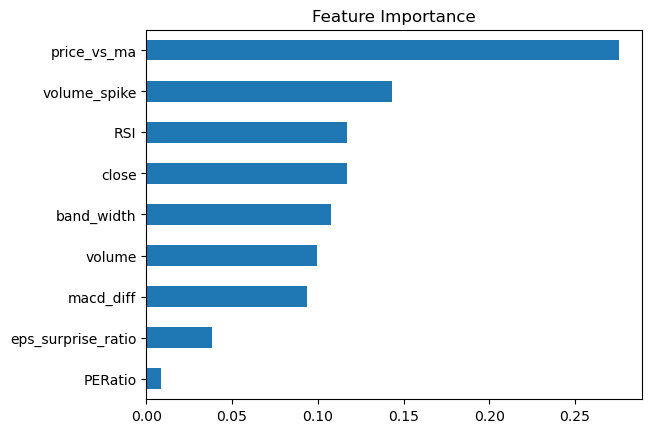

In [71]:
cols = feature_sets['Full']

X_train = train_df[cols]
y_train = train_df['downside_risk']

X_train = X_train.fillna(X_train.median())

rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X_train.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

## Gradient Boosting

#### Test different 

In [72]:
results_gbr = []

for name, cols in feature_sets.items():
    cols = [c for c in cols if c in df.columns]

    X_train = train_df[cols].copy()
    X_test = test_df[cols].copy()
    y_train = train_df['downside_risk']
    y_test = test_df['downside_risk']

    X_train = X_train.fillna(X_train.median())
    X_test = X_test.fillna(X_train.median())

    model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results_gbr.append({
        'Feature Set': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })

results_gbr = pd.DataFrame(results_gbr)
print(results_gbr)

  Feature Set       MAE      RMSE        R2
0       Basic  0.023286  0.029606 -0.221311
1   Technical  0.016092  0.020808  0.396707
2        Full  0.016274  0.021033  0.383585


#### Feature importance

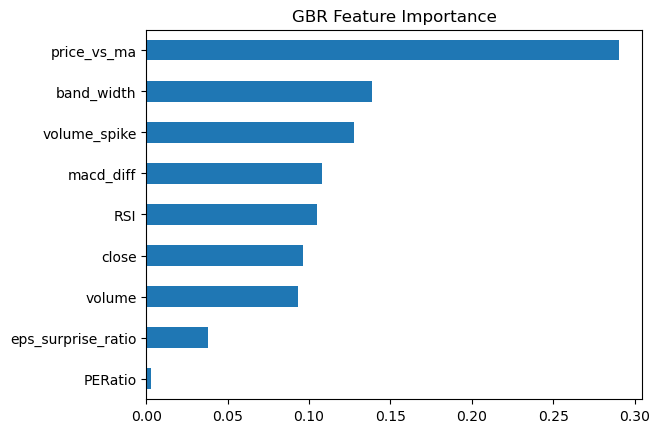

In [73]:
cols = feature_sets['Full']

X_train = train_df[cols].copy()
y_train = train_df['downside_risk']

X_train = X_train.fillna(X_train.median())

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

importance = pd.Series(gbr.feature_importances_, index=X_train.columns)

importance.sort_values().plot(kind='barh')
plt.title("GBR Feature Importance")
plt.show()

## Model Comparison

In [74]:
results_random = pd.DataFrame(results_random)

results_lr['Model'] = 'Linear'
results_rf['Model'] = 'Random Forest'
results_gbr['Model'] = 'Gradient Boosting'

results_lr['Split'] = 'Time'
results_rf['Split'] = 'Time'
results_gbr['Split'] = 'Time'

time_results = pd.concat([results_lr, results_rf, results_gbr], ignore_index=True)

all_results = pd.concat([results_random, time_results], ignore_index=True)

all_results = all_results[['Split', 'Model', 'Feature Set', 'MAE', 'RMSE', 'R2']]

print(all_results.sort_values('R2', ascending=False))

     Split              Model Feature Set       MAE      RMSE        R2
5     Time             Linear        Full  0.014319  0.018447  0.525832
4     Time             Linear   Technical  0.014991  0.019179  0.487459
1   Random      Random Forest        Full  0.012536  0.015411  0.447979
0   Random             Linear        Full  0.012488  0.015740  0.424150
2   Random  Gradient Boosting        Full  0.012488  0.015740  0.424150
10    Time  Gradient Boosting   Technical  0.016092  0.020808  0.396707
11    Time  Gradient Boosting        Full  0.016274  0.021033  0.383585
8     Time      Random Forest        Full  0.017278  0.022009  0.325035
7     Time      Random Forest   Technical  0.017334  0.022216  0.312275
3     Time             Linear       Basic  0.022063  0.028631 -0.142199
9     Time  Gradient Boosting       Basic  0.023286  0.029606 -0.221311
6     Time      Random Forest       Basic  0.023346  0.030075 -0.260362
